In [71]:
import pandas as pd
import numpy as np
import requests
import itertools
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn import svm
from sklearn.metrics import confusion_matrix,classification_report,f1_score,jaccard_score

In [3]:
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/cell_samples.csv"

In [5]:
filename='cell_samples.csv'

In [7]:
def download(url,filename):
    response=requests.get(url)
    if response.status_code==200:
        with open(filename,'wb')  as f:
            f.write(response.content)

    else:
        print(f"status code:{response.status_code}")

In [9]:
download(url,filename)

In [11]:
cell_df=pd.read_csv(filename)

In [13]:
cell_df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


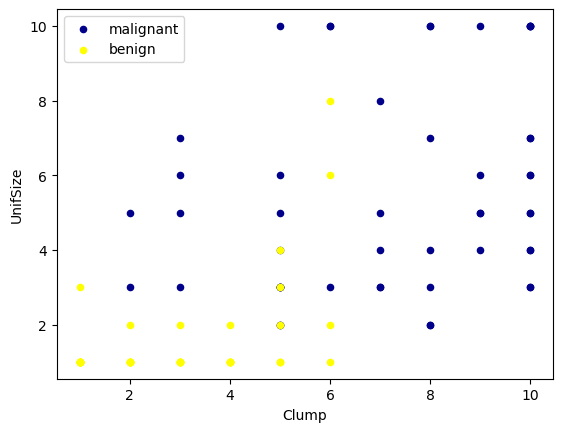

In [27]:
ax=cell_df[cell_df['Class']==4][0:50].plot(kind='scatter',x='Clump',y='UnifSize',color='DarkBlue',label='malignant')
cell_df[cell_df['Class']==2][0:50].plot(kind='scatter',x='Clump',y='UnifSize',color='Yellow',label='benign',ax=ax)

plt.show()

In [29]:
cell_df.dtypes

ID              int64
Clump           int64
UnifSize        int64
UnifShape       int64
MargAdh         int64
SingEpiSize     int64
BareNuc        object
BlandChrom      int64
NormNucl        int64
Mit             int64
Class           int64
dtype: object

In [35]:
cell_df=cell_df[pd.to_numeric(cell_df['BareNuc'],errors='coerce').notnull()]
cell_df['BareNuc']=cell_df['BareNuc'].astype('int')
cell_df.dtypes

ID             int64
Clump          int64
UnifSize       int64
UnifShape      int64
MargAdh        int64
SingEpiSize    int64
BareNuc        int32
BlandChrom     int64
NormNucl       int64
Mit            int64
Class          int64
dtype: object

In [37]:
feature_df=cell_df[['Clump','UnifSize','UnifShape','MargAdh','SingEpiSize','BareNuc','BlandChrom','NormNucl','Mit']]

In [41]:
X=np.asarray(feature_df)
X[0:5]

array([[ 5,  1,  1,  1,  2,  1,  3,  1,  1],
       [ 5,  4,  4,  5,  7, 10,  3,  2,  1],
       [ 3,  1,  1,  1,  2,  2,  3,  1,  1],
       [ 6,  8,  8,  1,  3,  4,  3,  7,  1],
       [ 4,  1,  1,  3,  2,  1,  3,  1,  1]], dtype=int64)

In [43]:
y=np.asarray(cell_df['Class'])
y[0:5]

array([2, 2, 2, 2, 2], dtype=int64)

In [47]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)
print('Train set:',X_train.shape,y_train.shape)
print('Test set:',X_test.shape,y_test.shape)

Train set: (546, 9) (546,)
Test set: (137, 9) (137,)


In [51]:
clf=svm.SVC(kernel='rbf')
clf.fit(X_train,y_train)

SVC()

In [53]:
yhat=clf.predict(X_test)
yhat[0:5]

array([2, 4, 2, 4, 2], dtype=int64)

In [59]:
def plot_confusion_matrix(cm,classes,normalize=False,title='Confusion Matrix',cmap=plt.cm.Blues):


    if normalize:
        cm=cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]
        print("Normalized confusion matrix")

    else:
        print('Confusion matrix,without normalization')

    print(cm)


    plt.imshow(cm,interpolation='nearest',cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks=np.arange(len(classes))
    plt.xticks(tick_marks,classes,rotation=45)
    plt.yticks(tick_marks,classes)


    fmt='.2f' if normalize else 'd'
    thresh=cm.max() / 2.
    for i,j  in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,format(cm[i,j],fmt),
                horizontalalignment="center",
                color="white" if cm[i,j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted Label')

    

              precision    recall  f1-score   support

           2       1.00      0.94      0.97        90
           4       0.90      1.00      0.95        47

    accuracy                           0.96       137
   macro avg       0.95      0.97      0.96       137
weighted avg       0.97      0.96      0.96       137

Confusion matrix,without normalization
[[85  5]
 [ 0 47]]


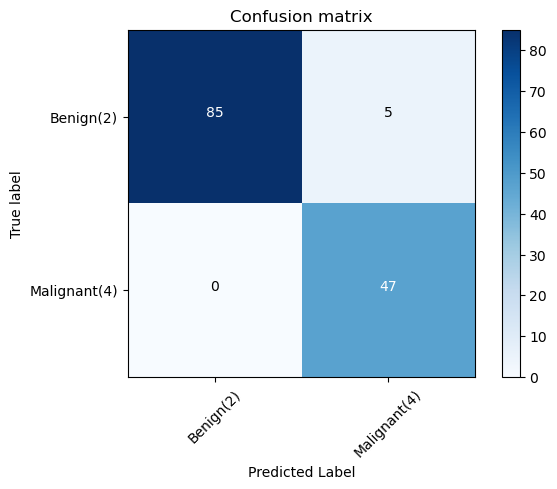

In [65]:
cnf_matrix = confusion_matrix(y_test, yhat, labels=[2,4])
np.set_printoptions(precision=2)

print (classification_report(y_test, yhat))


plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['Benign(2)','Malignant(4)'],normalize= False,  title='Confusion matrix')

In [73]:
print(f"F1 score:{f1_score(y_test,yhat,average='weighted')}")
print(f"jaccard indeksi:{jaccard_score(y_test,yhat,pos_label=2)}")

F1 score:0.9639038982104676
jaccard indeksi:0.9444444444444444


In [75]:
## Linear

In [77]:
clf2=svm.SVC(kernel='linear')
clf2.fit(X_train,y_train)
yhat2=clf2.predict(X_test)

print(f"F1 score:{f1_score(y_test,yhat2,average='weighted')}")
print(f"Jaccard score:{jaccard_score(y_test,yhat2,pos_label=2)}")

F1 score:0.9639038982104676
Jaccard score:0.9444444444444444


In [81]:
## Polynomiall

clf3=svm.SVC(kernel='poly')
clf3.fit(X_train,y_train)
yhat3=clf3.predict(X_test)

print(f"F1 score:{f1_score(y_test,yhat3,average='weighted')}")
print(f"jaccard score:{jaccard_score(y_test,yhat3,pos_label=2)}")

F1 score:0.9710669934861801
jaccard score:0.9555555555555556


In [108]:
## Sigmoid

clf4=svm.SVC(kernel='sigmoid')
clf4.fit(X_train,y_train)
yhat4=clf4.predict(X_test)


print(f"F1 score: {f1_score(y_test, yhat4, pos_label=4)}")
print(f"Jaccard score: {jaccard_score(y_test, yhat4, pos_label=4)}")

F1 score: 0.0
Jaccard score: 0.0


## 1.Linear
## 2.Polynomial
## 3.Radial basis function (RBF)
## 4.Sigmoid